In [1]:
%load_ext autoreload
%autoreload 2

# Bias correction

In [2]:
# get BCC files
from src import config

# bcc_nc_fps = list(config.env_dir.rglob("BCC*ssp370*.nc"))
bcc_nc_fps = list(config.env_dir.rglob("BCC*.nc"))
bcc_nc_fps

[PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/env_vars/DailySST/SSP3-7.0/BCC-CSM2-MR_ssp370_qdmCorrected_2031_2040.nc'),
 PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/env_vars/DailySST/SSP3-7.0/BCC-CSM2-MR_ssp370_qdmCorrected_2081_2100.nc'),
 PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/env_vars/DailySST/SSP3-7.0/BCC-CSM2-MR_ssp370_qdmCorrected_2061_2080.nc'),
 PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/env_vars/DailySST/SSP3-7.0/BCC-CSM2-MR_ssp370_qdmCorrected_2015_2030.nc'),
 PosixPath('/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/env_vars/DailySST/SSP3-7.

## CMIP historic → QDM forecast continuity

Sherwood QDM-corrected SST (1985–2014 calibration against satellite) lives under
`data/env_vars/DailySST/`. Raw CMIP6 historical point extracts (1850–2014, Kelvin)
are in `data/env_vars/cmip_historic_point_timeseries/`.

Joining raw historic directly to QDM forecast (2015+) leaves a large jump at the
2014/2015 boundary. We quantile-map the raw historic onto the QDM historic
reference (1985–2014), then append the QDM forecast to get a continuous series
back to 1850.

In [16]:
from src import config
from src.dataloading import cmip_sst

import matplotlib.pyplot as plt
import pandas as pd

MODEL = "BCC-CSM2-MR"
SCENARIO = "ssp370"

locations = cmip_sst.load_locations()
print(f"{len(locations):,} unique reef locations")

# Example: GBR point
example = locations[
    locations.latitude.between(-20, -5) & locations.longitude.between(140, 160)
].iloc[0]
LOC_ID = example.loc_id
LAT, LON = float(example.latitude), float(example.longitude)
example


5,486 unique reef locations


latitude     -19.817778
longitude    149.065806
loc_id       loc_000329
loc_idx             329
n_surveys             3
Name: 329, dtype: object

In [17]:
raw = cmip_sst.load_raw_historic_timeseries(MODEL, LOC_ID)
qdm_hist = cmip_sst.extract_qdm_historic_at_point(LAT, LON, MODEL)
qdm_fc = cmip_sst.extract_qdm_forecast_at_point(LAT, LON, MODEL, SCENARIO)

print(f"raw historic: {raw.time.min().date()} → {raw.time.max().date()}")
print(f"qdm historic: {qdm_hist.index.min().date()} → {qdm_hist.index.max().date()}")
print(f"qdm forecast: {qdm_fc.index.min().date()} → {qdm_fc.index.max().date()}")

jump_raw_to_fc = cmip_sst.boundary_jump(raw, qdm_fc, value_col="sst_c")
jump_qdm_to_fc = cmip_sst.boundary_jump(qdm_hist, qdm_fc)
print(f"2014→2015 jump (raw historic → QDM forecast): {jump_raw_to_fc:+.2f} °C")
print(f"2014→2015 jump (QDM historic → QDM forecast): {jump_qdm_to_fc:+.2f} °C")


raw historic: 1850-01-01 → 2014-12-31
qdm historic: 1985-01-01 → 2014-12-31
qdm forecast: 2015-01-01 → 2100-12-31
2014→2015 jump (raw historic → QDM forecast): -1.16 °C
2014→2015 jump (QDM historic → QDM forecast): -0.04 °C


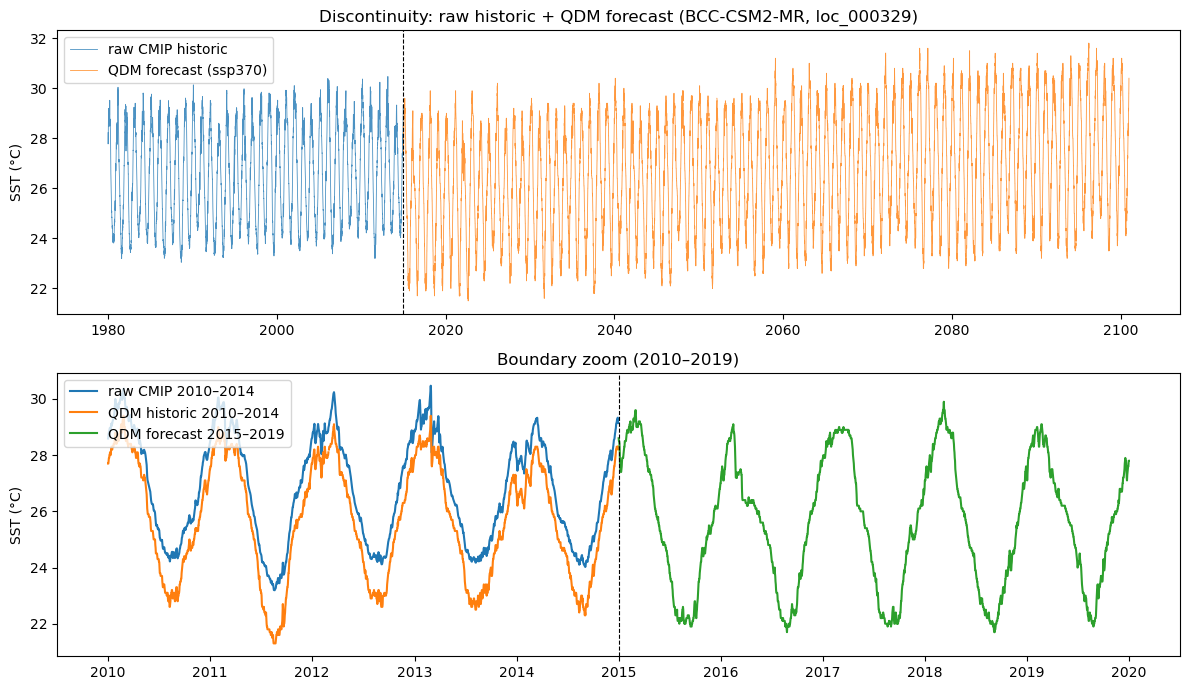

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# Full raw historic + QDM forecast (shows the discontinuity)
ax = axes[0]
raw_recent = raw.loc[raw.time >= "1980-01-01"]
ax.plot(raw_recent.time, raw_recent.sst_c, lw=0.6, alpha=0.8, label="raw CMIP historic")
ax.plot(
    qdm_fc.index, qdm_fc.values, lw=0.6, alpha=0.8, label=f"QDM forecast ({SCENARIO})"
)
ax.axvline(pd.Timestamp("2015-01-01"), color="k", ls="--", lw=0.8)
ax.set_title(f"Discontinuity: raw historic + QDM forecast ({MODEL}, {LOC_ID})")
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left")

# Zoom on boundary
ax = axes[1]
ax.plot(
    raw.loc[raw.time.dt.year.between(2010, 2014)].time,
    raw.loc[raw.time.dt.year.between(2010, 2014)].sst_c,
    label="raw CMIP 2010–2014",
)
ax.plot(
    qdm_hist.loc["2010":"2014"].index,
    qdm_hist.loc["2010":"2014"].values,
    label="QDM historic 2010–2014",
)
ax.plot(
    qdm_fc.loc["2015":"2019"].index,
    qdm_fc.loc["2015":"2019"].values,
    label="QDM forecast 2015–2019",
)
ax.axvline(pd.Timestamp("2015-01-01"), color="k", ls="--", lw=0.8)
ax.set_title("Boundary zoom (2010–2019)")
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


2014→2015 jump after QM (mapped historic → QDM forecast): -0.06 °C
2014→2015 jump in stitched continuous series: -0.06 °C


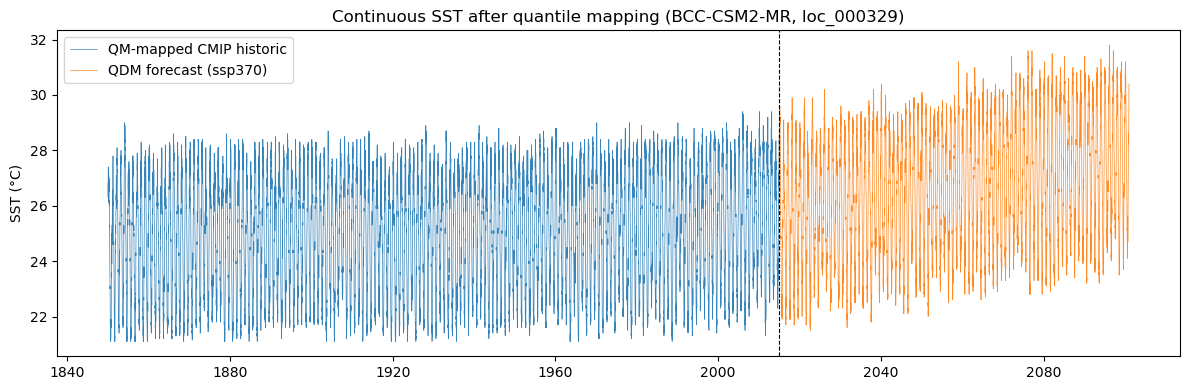

(        time  sst_c            source
 0 1850-01-01  26.80  historic_qmapped
 1 1850-01-02  26.75  historic_qmapped
 2 1850-01-03  26.50  historic_qmapped
 3 1850-01-04  26.40  historic_qmapped
 4 1850-01-05  26.30  historic_qmapped,
             time  sst_c        source
 91631 2100-12-27   29.9  forecast_qdm
 91632 2100-12-28   29.9  forecast_qdm
 91633 2100-12-29   30.1  forecast_qdm
 91634 2100-12-30   30.1  forecast_qdm
 91635 2100-12-31   30.4  forecast_qdm)

In [21]:
mapped = cmip_sst.quantile_map_historic_timeseries(raw, qdm_hist)
continuous = cmip_sst.build_continuous_timeseries(
    MODEL, LOC_ID, LAT, LON, scenario=SCENARIO
)

jump_mapped = cmip_sst.boundary_jump(mapped, qdm_fc, value_col="sst_qmapped")
jump_continuous = cmip_sst.boundary_jump(continuous, continuous, value_col="sst_c")
print(
    f"2014→2015 jump after QM (mapped historic → QDM forecast): {jump_mapped:+.2f} °C"
)
print(f"2014→2015 jump in stitched continuous series: {jump_continuous:+.2f} °C")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    mapped.time, mapped.sst_qmapped, lw=0.5, alpha=0.9, label="QM-mapped CMIP historic"
)
ax.plot(
    continuous.loc[continuous.source == "forecast_qdm"].time,
    continuous.loc[continuous.source == "forecast_qdm"].sst_c,
    lw=0.5,
    alpha=0.9,
    label=f"QDM forecast ({SCENARIO})",
)
ax.axvline(pd.Timestamp("2015-01-01"), color="k", ls="--", lw=0.8)
ax.set_title(f"Continuous SST after quantile mapping ({MODEL}, {LOC_ID})")
ax.set_ylabel("SST (°C)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

continuous.head(), continuous.tail()


Run ```python -m src.dataloading.map_cmip_sst --workers 8 --overwrite``` for full remapping

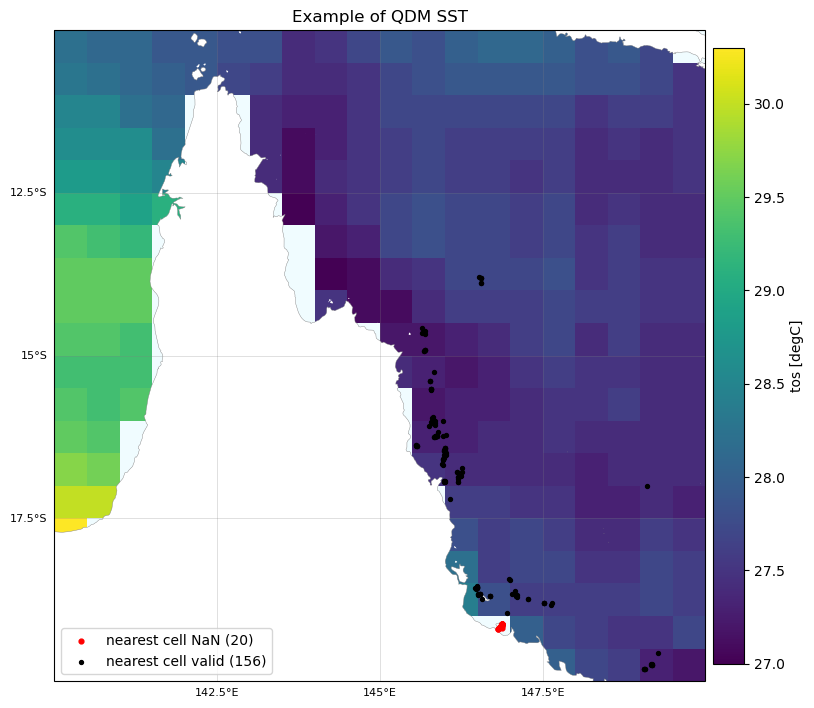

In [ ]:
# Plot QDM SST with reef points coloured by geographic-nearest grid cell validity
from src.plots import plot_utils
import xarray as xa
import numpy as np

fp = (
    config.env_dir
    / "DailySST/Historical/BCC-CSM2-MR_historical_qdmCorrected_1985_2014.nc"
)

qdm_eg = xa.open_dataset(fp)

fig, ax = plot_utils.generate_geo_axis(figsize=(10, 10), dpi=100)
lats = (-20, -10)
lons = (140, 150)
time_idx = 0

reef_check_pts = cmip_sst.load_locations()
pts_subset = reef_check_pts.loc[
    (reef_check_pts.latitude.between(min(lats), max(lats)))
    & (reef_check_pts.longitude.between(min(lons), max(lons)))
].copy()

qdm_eg.tos.sel(lat=slice(min(lats), max(lats)), lon=slice(min(lons), max(lons))).isel(
    time=time_idx
).plot(ax=ax, cbar_kwargs={"shrink": 0.8, "pad": 0.01})
ax = plot_utils.format_geo_axis(ax)

# Do NOT use interp(lat=plats, lon=plons): xarray builds a lat×lon meshgrid,
# not one value per point. Use the same nearest-cell lookup as the mapping pipeline.
cell_diag = cmip_sst.classify_points_on_qdm_grid(
    pts_subset.latitude.values,
    pts_subset.longitude.values,
    qdm_eg.tos,
    time_idx=time_idx,
)
pts_subset = pts_subset.assign(
    nearest_cell_valid=cell_diag["nearest_cell_valid"].to_numpy()
)

nan_pts = pts_subset.loc[~pts_subset.nearest_cell_valid]
good_pts = pts_subset.loc[pts_subset.nearest_cell_valid]

ax.scatter(
    nan_pts.longitude,
    nan_pts.latitude,
    c="r",
    s=12,
    label=f"nearest cell NaN ({len(nan_pts)})",
    zorder=3,
)
ax.scatter(
    good_pts.longitude,
    good_pts.latitude,
    c="k",
    s=8,
    label=f"nearest cell valid ({len(good_pts)})",
    zorder=3,
)
ax.legend(loc="lower left")
ax.set_title("Example of QDM SST")
qdm_eg.close()

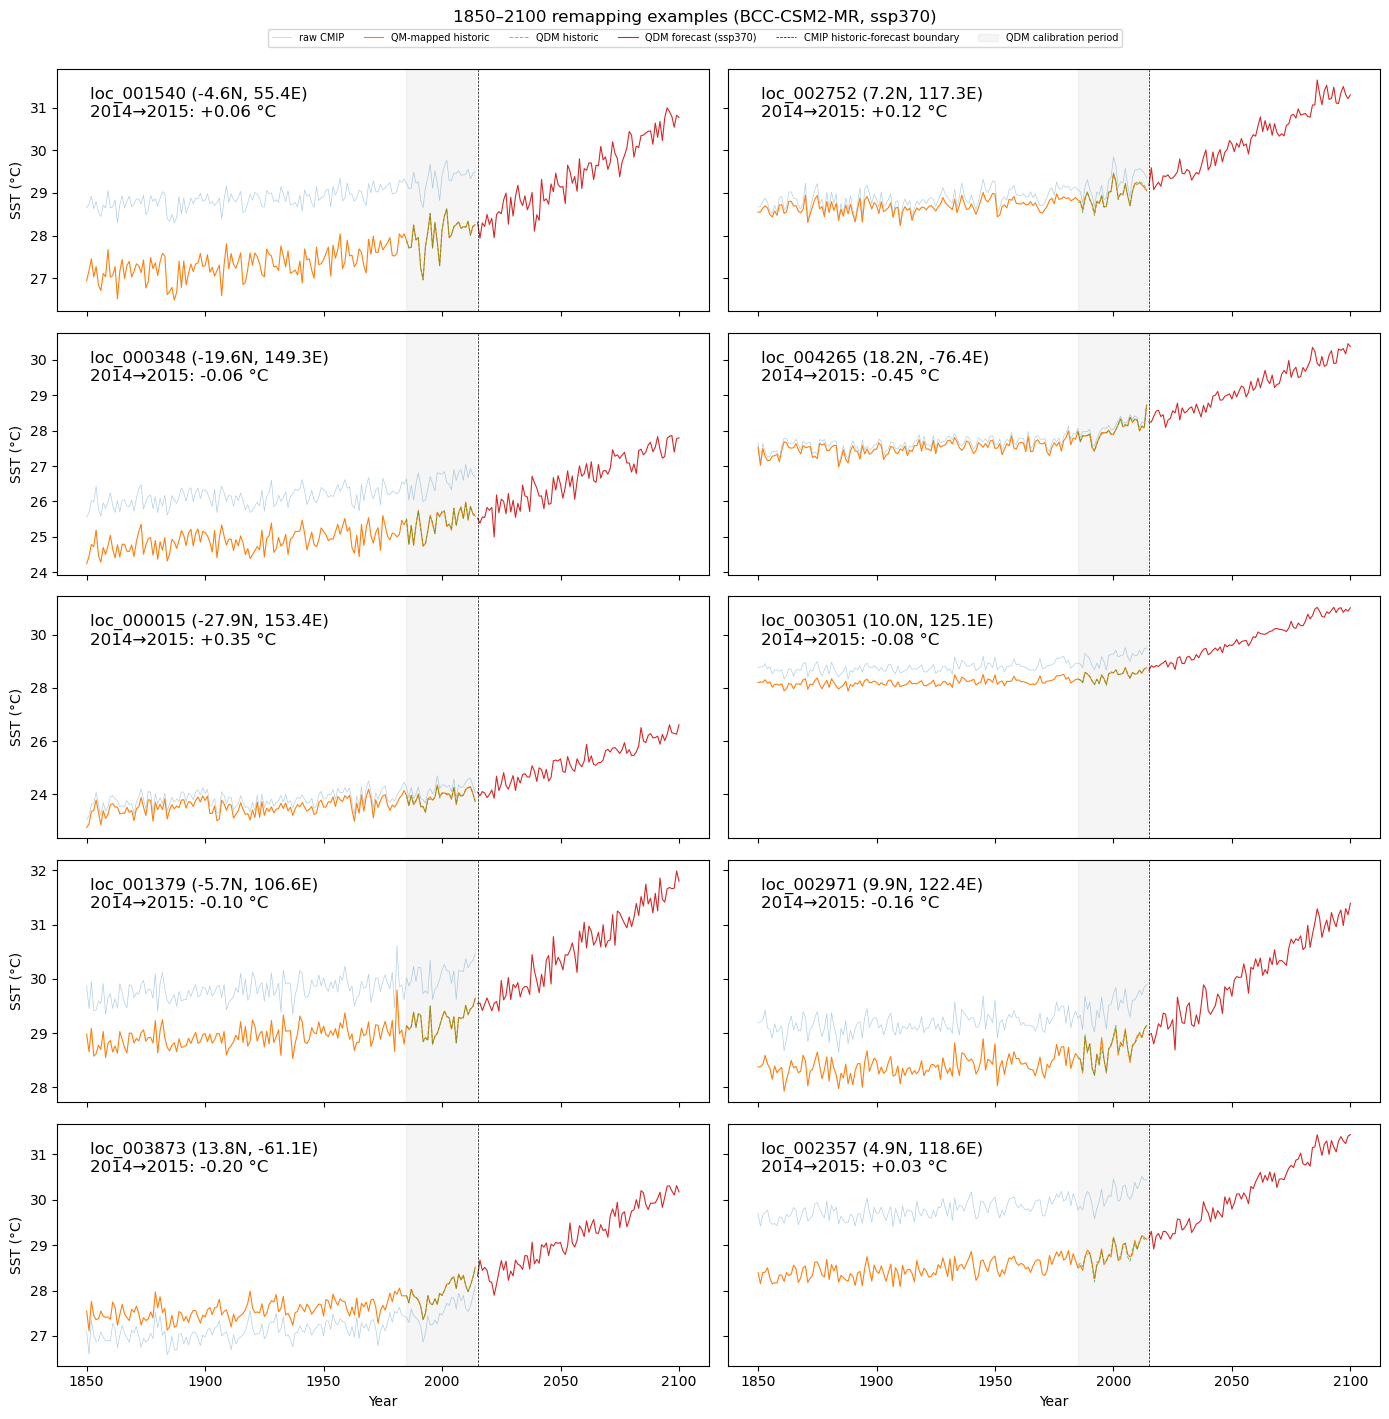

In [97]:
# 1850–2100 remapping examples: raw CMIP, QDM reference, and stitched output at N points
import numpy as np

N = 10


def _annual_mean(df, *, time_col="time", value_col="sst_c"):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col])
    return (
        out.assign(year=out[time_col].dt.year)
        .groupby("year", as_index=False)[value_col]
        .mean()
    )


MODEL = "BCC-CSM2-MR"
SCENARIO = "ssp370"

examples = locations.sample(N, random_state=0).reset_index(drop=True)
ncols = 2
nrows = int(np.ceil(N / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(14, 2.8 * nrows), sharex=True, sharey="row"
)
axes = np.atleast_1d(axes).ravel()

for ax, (idx, loc) in zip(axes, examples.iterrows()):
    loc_id = loc.loc_id
    lat, lon = loc.latitude, loc.longitude

    raw = cmip_sst.load_raw_historic_timeseries(MODEL, loc_id)
    qdm_hist = cmip_sst.extract_qdm_historic_at_point(lat, lon, MODEL)
    continuous = cmip_sst.load_mapped_timeseries(MODEL, loc_id, SCENARIO)

    raw_a = _annual_mean(raw)
    qdm_hist_a = _annual_mean(
        pd.DataFrame({"time": qdm_hist.index, "sst_c": qdm_hist.values})
    )
    qm_hist_a = _annual_mean(
        continuous.loc[continuous.source == "historic_qmapped"], value_col="sst_c"
    )
    fc_a = _annual_mean(
        continuous.loc[continuous.source == "forecast_qdm"], value_col="sst_c"
    )

    ax.plot(raw_a.year, raw_a.sst_c, lw=0.5, alpha=0.35, color="C0", label="raw CMIP")
    ax.plot(
        qm_hist_a.year, qm_hist_a.sst_c, lw=0.8, color="C1", label="QM-mapped historic"
    )
    ax.plot(
        qdm_hist_a.year,
        qdm_hist_a.sst_c,
        lw=0.7,
        alpha=0.65,
        color="C2",
        ls="--",
        label="QDM historic",
    )
    ax.plot(
        fc_a.year, fc_a.sst_c, lw=0.8, color="C3", label=f"QDM forecast ({SCENARIO})"
    )
    ax.axvline(
        2015, color="k", ls="--", lw=0.5, label="CMIP historic-forecast boundary"
    )
    ax.axvspan(1985, 2014, color="gray", alpha=0.08, label="QDM calibration period")
    jump = cmip_sst.boundary_jump(continuous, continuous, value_col="sst_c")

    ax.annotate(
        f"{loc_id} ({lat:.1f}N, {lon:.1f}E)\n2014→2015: {jump:+.2f} °C",
        xy=(0.05, 0.8),
        xycoords="axes fraction",
        fontsize=12,
    )
    if idx % ncols == 0:
        ax.set_ylabel("SST (°C)")

for ax in axes[len(examples) :]:
    ax.set_visible(False)

# Plot legend for the whole figure below the suptitle
# Get handles and labels from the first axes (assume all share the same curves)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), fontsize=7, ncol=6
)
for ax in axes[(nrows - 1) * ncols :]:
    if ax.get_visible():
        ax.set_xlabel("Year")

fig.suptitle(f"1850–2100 remapping examples ({MODEL}, {SCENARIO})", y=1.01)
fig.tight_layout()
plt.show()


# Cyclones

In [1]:
import xarray as xa
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

import cartopy.feature as cfeature
import cartopy.crs as ccrs


# custom
from src.plots import plot_utils
from src import config


fp = config.data_dir / "cyclones" / "cyclones.nc"
cyclones_xa = xa.open_dataset(fp)

Interpolating tracks for 13544 historical storms...


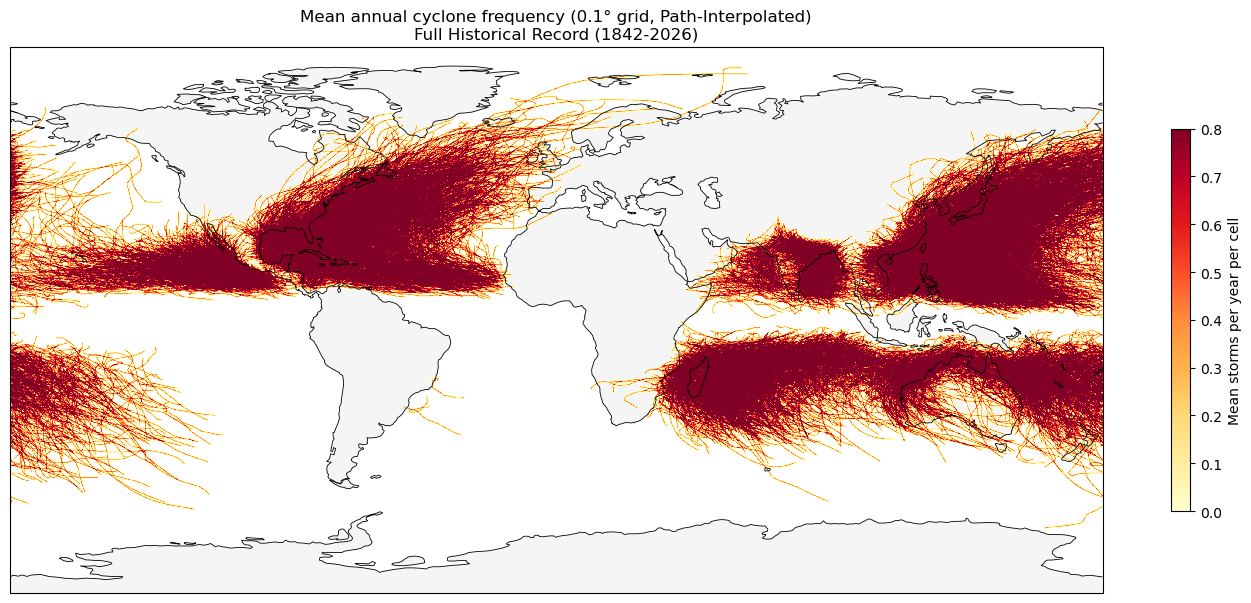

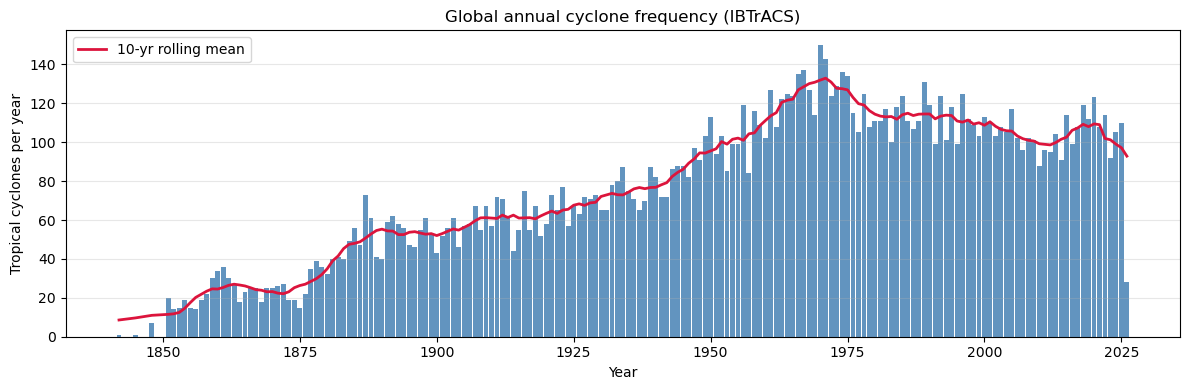

In [2]:
GRID_STEP = 0.1  # degrees (~11 km)

# Prepare dataframe from your xarray object
valid = cyclones_xa.lon.notnull() & cyclones_xa.lat.notnull()
storm_year = cyclones_xa.time.dt.year.where(valid)

track_df = (
    xa.Dataset(
        {
            "year": storm_year,
            "lon": cyclones_xa.lon,
            "lat": cyclones_xa.lat,
            "storm": cyclones_xa.storm,
            "time": cyclones_xa.time,
        }
    )
    .to_dataframe()
    .reset_index()
    .dropna(subset=["year", "lon", "lat", "storm"])
)
track_df["year"] = track_df["year"].astype(int)

print(f"Interpolating tracks for {track_df['storm'].nunique()} historical storms...")


# --- Track Interpolation Function ---
def interpolate_storm_track(group):
    if len(group) < 2:
        return group[["year", "lon", "lat", "storm"]]

    group = group.sort_values("time")
    lons = group["lon"].values
    lats = group["lat"].values

    # Handle International Date Line crossings smoothly
    lons_unwrapped = np.unwrap(lons, period=360)

    interp_lons = []
    interp_lats = []

    for i in range(len(group) - 1):
        lon1, lon2 = lons_unwrapped[i], lons_unwrapped[i + 1]
        lat1, lat2 = lats[i], lats[i + 1]

        # Calculate spatial distance in degrees to determine sub-steps
        dist = np.hypot(lon2 - lon1, lat2 - lat1)

        # Ensure we place points closer together than our 0.1° grid cell size
        n_pts = max(2, int(np.ceil(dist / (GRID_STEP * 0.5))))

        interp_lons.extend(np.linspace(lon1, lon2, n_pts)[:-1])
        interp_lats.extend(np.linspace(lat1, lat2, n_pts)[:-1])

    # Append the final point of the track
    interp_lons.append(lons_unwrapped[-1])
    interp_lats.append(lats[-1])

    # Wrap longitudes back to the standard [-180, 180] range
    interp_lons = (np.array(interp_lons) + 180) % 360 - 180

    return pd.DataFrame(
        {
            "year": group["year"].iloc[0],  # Assign to the storm's origin year
            "lon": interp_lons,
            "lat": interp_lats,
            "storm": group["storm"].iloc[0],
        }
    )


# Run interpolation across all storms (takes a brief moment to process the full history)
interpolated_tracks_list = [
    interpolate_storm_track(grp) for _, grp in track_df.groupby("storm")
]
interp_df = pd.concat(interpolated_tracks_list, ignore_index=True)

# --- Spatial Binning Setup ---
lon_edges = np.arange(-180, 180 + GRID_STEP, GRID_STEP)
lat_edges = np.arange(-90, 90 + GRID_STEP, GRID_STEP)
lon_centers = lon_edges[:-1] + GRID_STEP / 2
lat_centers = lat_edges[:-1] + GRID_STEP / 2

interp_df["lon_i"] = np.clip(
    np.digitize(interp_df["lon"], lon_edges) - 1, 0, len(lon_edges) - 2
)
interp_df["lat_i"] = np.clip(
    np.digitize(interp_df["lat"], lat_edges) - 1, 0, len(lat_edges) - 2
)

# Deduplicate so a single storm only counts once per grid cell, per year
cell_year_storms = interp_df.drop_duplicates(subset=["year", "lat_i", "lon_i", "storm"])

storms_per_cell_year = (
    cell_year_storms.groupby(["year", "lat_i", "lon_i"])
    .size()
    .rename("n_storms")
    .reset_index()
)

mean_annual_by_cell = storms_per_cell_year.groupby(["lat_i", "lon_i"])[
    "n_storms"
].mean()

# Populate the final matrix
mean_grid = np.zeros((len(lat_centers), len(lon_centers)), dtype=float)
for (lat_i, lon_i), value in mean_annual_by_cell.items():
    mean_grid[int(lat_i), int(lon_i)] = value

# --- Light Spatial Filter ---
# Since 19th-century logs are heavily locked to exact integer coordinates, a light
# Gaussian blur (sigma=1.0) eliminates remaining artificial linear spikes.
smoothed_grid = gaussian_filter(mean_grid, sigma=1.0)
smoothed_grid[smoothed_grid < 1e-4] = np.nan

# Rebuild Xarray DataArray
cyclone_freq_annual_mean = xa.DataArray(
    smoothed_grid,
    coords={"lat": lat_centers, "lon": lon_centers},
    dims=["lat", "lon"],
    name="mean_annual_cyclone_count",
    attrs={
        "long_name": "Mean annual tropical cyclone count per grid cell",
        "units": "storms yr-1",
        "grid_step_deg": GRID_STEP,
        "years": f"{int(track_df['year'].min())}-{int(track_df['year'].max())}",
    },
)

# --- Plotting ---
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    cyclone_freq_annual_mean.lon,
    cyclone_freq_annual_mean.lat,
    cyclone_freq_annual_mean,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    vmin=0,
    vmax=0.8,  # Adjusted scale for interpolated density distribution
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
ax.set_global()

plt.colorbar(mesh, ax=ax, label="Mean storms per year per cell", shrink=0.7)
ax.set_title(
    f"Mean annual cyclone frequency ({GRID_STEP}° grid, Path-Interpolated)\n"
    f"Full Historical Record ({cyclone_freq_annual_mean.attrs['years']})"
)
plt.tight_layout()
plt.show()


# --- Global annual frequency: unique storms per calendar year ---
annual_freq = (
    track_df.groupby("year")["storm"].nunique().sort_index().rename("n_storms")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annual_freq.index, annual_freq.values, color="steelblue", alpha=0.85, width=0.9)
roll = annual_freq.rolling(10, center=True, min_periods=5).mean()
ax.plot(
    roll.index, roll.values, color="crimson", linewidth=2, label="10-yr rolling mean"
)
ax.set_xlabel("Year")
ax.set_ylabel("Tropical cyclones per year")
ax.set_title("Global annual cyclone frequency (IBTrACS)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# MPAs

Using https://www.protectedplanet.net/en/thematic-areas/wdpa?tab=WDPA

In [3]:
from glob import glob
import geopandas as gpd
from tqdm.auto import tqdm

shapefiles_fps = list(config.mpas_dir.glob("WDPA_*shp*/WDPA_*polygons.shp"))

# open each shapefile as a gdf and concatenate them
mpas_gdf = gpd.GeoDataFrame()
for fp in tqdm(shapefiles_fps):
    mpas_gdf = pd.concat([mpas_gdf, gpd.read_file(fp)])

mpas_gdf.rename(columns=str.lower, inplace=True)
mpas_gdf.head()


  0%|          | 0/3 [00:00<?, ?it/s]

,site_id,site_pid,site_type,name_eng,name,desig,desig_eng,desig_type,iucn_cat,int_crit,...,mang_plan,verif,metadataid,prnt_iso3,iso3,supp_info,cons_obj,inlnd_wtrs,oecm_asmt,geometry
0,555648064,555648064,PA,5-02-490,5-02-490,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.4856 -35.72779, 174.48577 -35.72..."
1,555648065,555648065,PA,5-02-491,5-02-491,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.20955 -35.25723, 174.21016 -35.2..."
2,555648066,555648066,PA,5-02-526,5-02-526,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.47979 -35.76682, 174.48002 -35.7..."
3,555648067,555648067,PA,5-02-529,5-02-529,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"MULTIPOLYGON (((173.74614 -35.29146, 173.74655..."
4,555648068,555648068,PA,5-02-532,5-02-532,Open Space Covenant,Open Space Covenant,National,IV,Not Applicable,...,Not Reported,State Verified,1944,NZL,NZL,Not Applicable,Not Applicable,Not Reported,Not Applicable,"POLYGON ((174.31469 -35.66002, 174.31469 -35.6..."


<GeoAxes: >

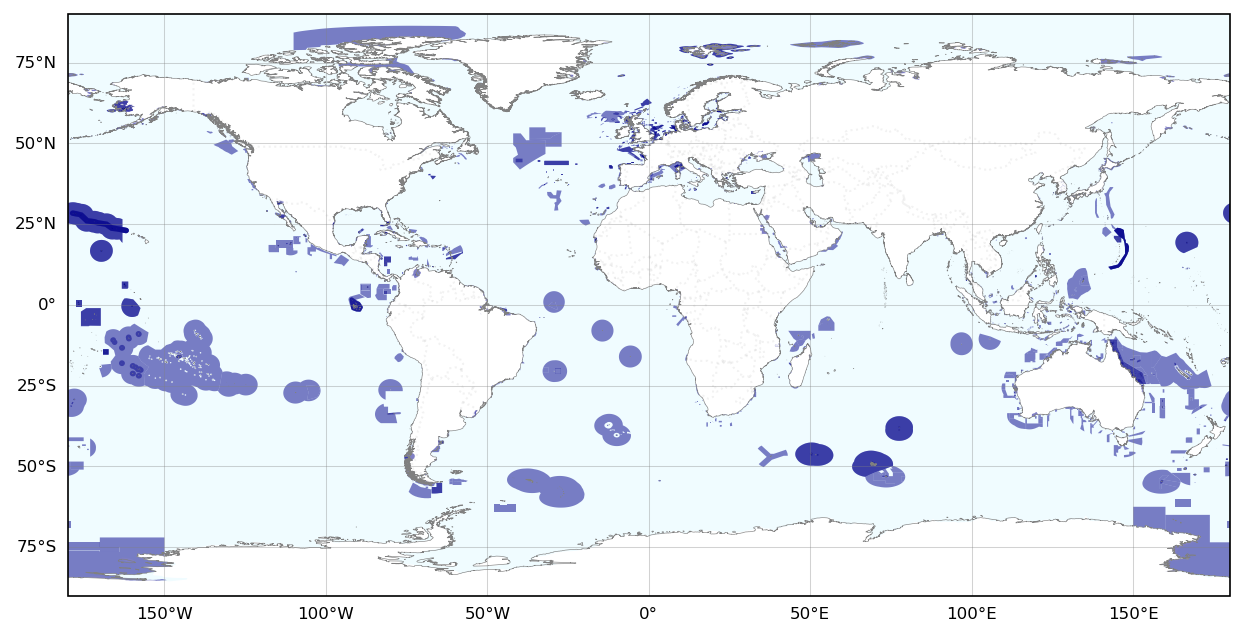

In [4]:
# filter for marine/coastal
mpas_gdf = mpas_gdf[mpas_gdf["realm"].isin(["Marine", "Coastal"])]

fig, ax = plot_utils.generate_geo_axis(
    figsize=(10, 10),
    map_proj=ccrs.PlateCarree(),
    dpi=150,
    central_longitude=0,
    central_latitude=0,
)
plot_utils.format_geo_axis(ax)

mpas_gdf.plot(ax=ax, color="darkblue", alpha=0.5)

In [ ]:
# maybe useful: gov_type/own_type (interesting to investigate which orgs do best)
# ? status_yr, inlnd_wtrs
# iucn_cat is e.g. managed area, monument, national park etc. (https://en.wikipedia.org/wiki/IUCN_protected_area_categories)

# TODO: for now (and likely future): assign points a binary protected/not protected. And look for datasets contextualising the effectiveness of different MPAs

# Population

In [ ]:
# future: https://hub.worldpop.org/geodata/summary?id=110984

# base URL: https://hub.worldpop.org/geodata/summary?id=80021